# Лабораторна робота 4: Реалізація та Аналіз Дерев Рішень для Класифікації

## Завдання
Реалізація дерева рішень з використанням Gini Index, прунінг, порівняння з sklearn моделями, інженерія ознак та feature selection.

**Цільова змінна:** `Health_Issues` (None, Mild, Moderate, Severe)

**Метрики:** Sensitivity, Specificity, F1-score, Confusion Matrix, MCC


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, matthews_corrcoef
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Налаштування для візуалізації
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline


## 1. Завантаження та обробка датасету

### Теоретичні основи обробки датасету

**Мета обробки датасету:**
- Підготовка даних до навчання моделі класифікації
- Видалення нерелевантних ознак (ID)
- Обробка відсутніх значень
- Підготовка цільової змінної для класифікації

**Важливі кроки:**
1. **Видалення ID** - ідентифікатор не містить інформації для передбачення
2. **Перевірка цільової змінної** - перевіряємо розподіл класів та наявність відсутніх значень
3. **Обробка відсутніх значень** - замінюємо NaN на 'None' якщо це відповідає логіці задачі

**Цільова змінна Health_Issues:**
- Категоріальна змінна з класами: None, Mild, Moderate, Severe
- Потрібно переконатися, що всі значення коректно оброблені


In [65]:
# Завантаження датасету
df = pd.read_csv('synthetic_coffee_health_10000.csv')
print(f"Розмір датасету: {df.shape}")
print(f"\nПерші 5 рядків:")
df.head()


Розмір датасету: (10000, 16)

Перші 5 рядків:


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [66]:
# Перевірка цільової змінної
print("Розподіл Health_Issues:")
print(df['Health_Issues'].value_counts())
print(f"\nУнікальні значення: {df['Health_Issues'].unique()}")
print(f"\nІнформація про датасет:")
df.info()


Розподіл Health_Issues:
Health_Issues
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64

Унікальні значення: [nan 'Mild' 'Moderate' 'Severe']

Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  obje

In [67]:
# Видалення ID та підготовка даних
X = df.drop(['ID', 'Health_Issues'], axis=1)
y = df['Health_Issues'].copy()

# Перевірка наявності None в Health_Issues
print("Перевірка значень Health_Issues:")
print(y.value_counts())
print(f"\nЄ None значення: {y.isna().sum()}")
print(f"Порожні рядки: {(y == '').sum() if y.dtype == 'object' else 0}")

# Якщо є порожні значення, замінимо їх на 'None'
if y.isna().sum() > 0:
    y = y.fillna('None')
elif (y == '').sum() > 0:
    y = y.replace('', 'None')

print(f"\nПісля обробки:")
print(y.value_counts())


Перевірка значень Health_Issues:
Health_Issues
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64

Є None значення: 5941
Порожні рядки: 0

Після обробки:
Health_Issues
None        5941
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64


## 2. Інженерія ознак (Feature Engineering)

### Теоретичні основи інженерії ознак

**Інженерія ознак** - це процес створення нових ознак з існуючих даних для покращення якості моделі.

#### 1. Взаємодійні ознаки (Interaction Features)
Створюються шляхом множення або комбінації існуючих ознак:
- **Coffee_Sleep_Interaction** = Coffee_Intake × Sleep_Hours
  - Відображає взаємодію між споживанням кави та сном
- **Caffeine_BMI_Interaction** = Caffeine_mg × BMI
  - Враховує вплив кофеїну на різні типи тіла
- **Stress_Activity_Interaction** = Physical_Activity_Hours × Stress_Level (закодований)
  - Показує як фізична активність впливає на стрес

**Навіщо:** Деякі взаємодії між ознаками можуть бути важливішими для передбачення, ніж окремі ознаки.

#### 2. Бінінг (Binning)
Перетворення неперервних змінних на категоріальні:
- **Age_Binned**: розбиття віку на категорії (Young: 0-30, Middle: 30-50, Old: 50+)
- **Переваги:** 
  - Зменшує вплив викидів
  - Може виявити нелінійні залежності
  - Спрощує інтерпретацію

#### 3. Поліноміальні ознаки
Створення квадратичних та інших степеневих ознак:
- **Coffee_Intake_Squared** = Coffee_Intake²
- **Sleep_Hours_Squared** = Sleep_Hours²
- **BMI_Squared** = BMI²

**Навіщо:** Дозволяє моделі виявляти нелінійні залежності між ознаками та цільовою змінною.

#### 4. One-Hot Encoding
Перетворення категоріальних змінних у бінарні ознаки:
- Кожна категорія стає окремою бінарною ознакою
- **Приклад:** Gender (Male, Female) → Gender_Male, Gender_Female
- **Переваги:** Дерева рішень можуть ефективно працювати з бінарними ознаками

#### 5. Видалення висококорельованих ознак
Ознаки з кореляцією > 0.95 видаляються:
- **Формула кореляції Пірсона:**
  $$r_{xy} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$
- **Навіщо:** Висококорельовані ознаки несуть дублюючу інформацію та можуть спричинити перенавчання

#### 6. Нормалізація (Z-score Standardization)
Перетворення ознак до стандартного розподілу:
- **Формула:** $z = \frac{x - \mu}{\sigma}$
- Де $\mu$ - середнє, $\sigma$ - стандартне відхилення
- **Результат:** Ознаки мають середнє = 0 та стандартне відхилення = 1
- **Навіщо:** Хоча дерева рішень не вимагають нормалізації, це може допомогти при порівнянні з іншими алгоритмами


In [68]:
# Створення копії для інженерії ознак
X_fe = X.copy()

# 1. Створення взаємодійних ознак
X_fe['Coffee_Sleep_Interaction'] = X_fe['Coffee_Intake'] * X_fe['Sleep_Hours']
X_fe['Caffeine_BMI_Interaction'] = X_fe['Caffeine_mg'] * X_fe['BMI']
X_fe['Stress_Activity_Interaction'] = X_fe['Physical_Activity_Hours'] * (X_fe['Stress_Level'].map({'Low': 1, 'Medium': 2, 'High': 3}) if 'Stress_Level' in X_fe.columns else 0)

# 2. Бінінг віку
X_fe['Age_Binned'] = pd.cut(X_fe['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle', 'Old'])

# 3. Поліноміальні ознаки
X_fe['Coffee_Intake_Squared'] = X_fe['Coffee_Intake'] ** 2
X_fe['Sleep_Hours_Squared'] = X_fe['Sleep_Hours'] ** 2
X_fe['BMI_Squared'] = X_fe['BMI'] ** 2

print("Додано нові ознаки:")
print(f"Початкова кількість ознак: {X.shape[1]}")
print(f"Після інженерії: {X_fe.shape[1]}")


Додано нові ознаки:
Початкова кількість ознак: 14
Після інженерії: 21


In [69]:
# Кодування категоріальних ознак
# Перевіряємо, які колонки дійсно категоріальні
cat_cols = ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Occupation']

# Додаємо Age_Binned, якщо він існує
if 'Age_Binned' in X_fe.columns:
    cat_cols.append('Age_Binned')

# Smoking та Alcohol_Consumption вже числові (0/1), тому не кодуємо їх
# Перевіряємо, які колонки дійсно є категоріальними (object або category)
actual_cat_cols = [col for col in cat_cols if col in X_fe.columns and X_fe[col].dtype in ['object', 'category']]

print(f"Категоріальні колонки для кодування: {actual_cat_cols}")
print(f"Smoking та Alcohol_Consumption залишаються числовими (0/1)")

# One-hot encoding для категоріальних ознак
X_encoded = pd.get_dummies(X_fe, columns=actual_cat_cols, drop_first=False)

print(f"\nПісля кодування: {X_encoded.shape[1]} ознак")
print(f"Початкова кількість: {X_fe.shape[1]} ознак")
print(f"\nПерші 5 рядків:")
X_encoded.head()


Категоріальні колонки для кодування: ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Occupation', 'Age_Binned']
Smoking та Alcohol_Consumption залишаються числовими (0/1)

Після кодування: 53 ознак
Початкова кількість: 21 ознак

Перші 5 рядків:


,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption,Coffee_Sleep_Interaction,...,Stress_Level_Low,Stress_Level_Medium,Occupation_Healthcare,Occupation_Office,Occupation_Other,Occupation_Service,Occupation_Student,Age_Binned_Young,Age_Binned_Middle,Age_Binned_Old
0,40,3.5,328.1,7.5,24.9,78,14.5,0,0,26.25,...,True,False,False,False,True,False,False,False,True,False
1,33,1.0,94.1,6.2,20.0,67,11.0,0,0,6.20,...,True,False,False,False,False,True,False,False,True,False
2,42,5.3,503.7,5.9,22.7,59,11.2,0,0,31.27,...,False,True,False,True,False,False,False,False,True,False
3,53,2.6,249.2,7.3,24.7,71,6.6,0,0,18.98,...,True,False,False,False,True,False,False,False,False,True
4,32,3.1,298.0,5.3,24.1,76,8.5,0,1,16.43,...,False,True,False,False,False,False,True,False,True,False


In [70]:
# Видалення висококорельованих ознак (кореляція > 0.95)
correlation_matrix = X_encoded.select_dtypes(include=[np.number]).corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)]

if high_corr_features:
    print(f"Видалено {len(high_corr_features)} висококорельованих ознак: {high_corr_features[:10]}")
    X_encoded = X_encoded.drop(columns=high_corr_features)

print(f"Після видалення висококорельованих: {X_encoded.shape[1]} ознак")


Видалено 4 висококорельованих ознак: ['Caffeine_mg', 'Caffeine_BMI_Interaction', 'Sleep_Hours_Squared', 'BMI_Squared']
Після видалення висококорельованих: 49 ознак


In [71]:
# Нормалізація числових ознак (z-score)
numeric_cols = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 
                'Heart_Rate', 'Physical_Activity_Hours', 'Coffee_Sleep_Interaction',
                'Caffeine_BMI_Interaction', 'Coffee_Intake_Squared', 
                'Sleep_Hours_Squared', 'BMI_Squared']

# Залишаємо тільки ті, що існують
numeric_cols = [col for col in numeric_cols if col in X_encoded.columns]

scaler = StandardScaler()
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

print("Нормалізацію виконано")
print(f"Фінальна кількість ознак: {X_encoded.shape[1]}")


Нормалізацію виконано
Фінальна кількість ознак: 49


In [72]:
# Кодування цільової змінної
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Класи після кодування:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i}: {class_name}")

print(f"\nРозподіл класів:")
unique, counts = np.unique(y_encoded, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Клас {u} ({label_encoder.classes_[u]}): {c} ({c/len(y_encoded)*100:.2f}%)")


Класи після кодування:
0: Mild
1: Moderate
2: None
3: Severe

Розподіл класів:
Клас 0 (Mild): 3579 (35.79%)
Клас 1 (Moderate): 463 (4.63%)
Клас 2 (None): 5941 (59.41%)
Клас 3 (Severe): 17 (0.17%)


In [73]:
# Поділ на тренувальну та тестову вибірки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded.values, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Поділ тренувальної вибірки на train та validation для прунінгу
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Розміри вибірок:")
print(f"Тренувальна: {X_train_main.shape[0]}")
print(f"Валідаційна: {X_val.shape[0]}")
print(f"Тестова: {X_test.shape[0]}")
print(f"Кількість ознак: {X_train_main.shape[1]}")


Розміри вибірок:
Тренувальна: 6400
Валідаційна: 1600
Тестова: 2000
Кількість ознак: 49


## 3. Реалізація MyDecisionTree з Gini Index

### Теоретичні основи Дерев Рішень

**Дерево рішень** - це алгоритм машинного навчання, який будує ієрархічну структуру для класифікації або регресії.

#### Структура дерева:
- **Кореневий вузол** - початковий вузол з усіма даними
- **Внутрішні вузли** - містять умови розділу (ознака та поріг)
- **Листові вузли** - містять фінальний клас (прогноз)

#### Алгоритм побудови дерева:
1. Обчислити Gini impurity для поточного вузла
2. Якщо Gini = 0 або досягнуто критерій зупинки → створити листовий вузол
3. Для кожної ознаки та порогу обчислити зважену Gini після розділу
4. Обрати ознаку/поріг з мінімальною зваженою Gini
5. Рекурсивно застосувати до піддерев

### Gini Impurity (Gini Index)

**Gini impurity** вимірює неоднорідність вузла. Нижче значення = кращий розділ.

#### Формула Gini impurity:
$$Gini(D) = 1 - \sum_{i=1}^{c} p_i^2$$

Де:
- $D$ - набір даних у вузлі
- $c$ - кількість класів
- $p_i$ - частка зразків класу $i$ у вузлі

**Властивості:**
- Gini = 0 → вузол чистий (всі зразки одного класу)
- Gini = 0.5 → максимальна неоднорідність (для бінарної класифікації)
- Gini ∈ [0, 0.5] для бінарної класифікації

#### Зважена Gini для розділу:
$$Gini_{split} = \frac{n_{left}}{n} \cdot Gini(D_{left}) + \frac{n_{right}}{n} \cdot Gini(D_{right})$$

Де:
- $n$ - кількість зразків у батьківському вузлі
- $n_{left}$, $n_{right}$ - кількість зразків у лівому/правому піддереві
- $D_{left}$, $D_{right}$ - дані у лівому/правому піддереві

#### Gini Gain (зменшення Gini):
$$Gini_{gain} = Gini(D) - Gini_{split}$$

**Чим більше Gini Gain, тим кращий розділ!**

### Feature Importance (Важливість ознак)

Важливість ознаки вимірює внесок кожної ознаки у зменшення неоднорідності.

#### Формула важливості для вузла:
$$Importance_{node} = Gini_{gain} \cdot \frac{n_{node}}{n_{total}}$$

Де:
- $Gini_{gain}$ - зменшення Gini при розділі
- $n_{node}$ - кількість зразків у вузлі
- $n_{total}$ - загальна кількість зразків у датасеті

#### Сумарна важливість ознаки:
$$Importance_{feature} = \sum_{nodes \ using \ feature} Importance_{node}$$

#### Нормалізація:
$$Importance_{normalized} = \frac{Importance_{feature}}{\sum_{all \ features} Importance_{feature}}$$

**Результат:** Сума важливостей всіх ознак = 1 (або 100%)

### Критерії зупинки:
- **max_depth** - максимальна глибина дерева
- **min_samples** - мінімальна кількість зразків у вузлі
- **Gini = 0** - вузол чистий (всі зразки одного класу)

### Прогнозування:
1. Почати з кореневого вузла
2. Перевірити умову: якщо ознака ≤ поріг → перейти вліво, інакше → вправо
3. Повторювати до досягнення листового вузла
4. Повернути клас листового вузла (majority class)


In [74]:
# Реалізація класу MyDecisionTree
class MyDecisionTree:
    def __init__(self, max_depth=5, min_samples=2):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.feature_importance = None
        self.tree = None
        self.n_total = None
    
    def get_params(self, deep=True):
        """Повертає параметри класу для сумісності з sklearn."""
        return {
            'max_depth': self.max_depth,
            'min_samples': self.min_samples
        }
    
    def set_params(self, **params):
        """Встановлює параметри класу для сумісності з sklearn."""
        for key, value in params.items():
            setattr(self, key, value)
        return self

    def gini(self, y):
        """Розрахунок Gini impurity для вузла."""
        if len(y) == 0:
            return 0
        
        counts = Counter(y)
        n = len(y)
        gini = 1.0
        
        for count in counts.values():
            p = count / n
            gini -= p ** 2
        
        return gini

    def best_split(self, X, y):
        """Знаходить найкращий розділ для вузла."""
        best_gini = float('inf')
        best_feature = None
        best_threshold = None
        best_gini_gain = 0
        
        n_samples = len(y)
        current_gini = self.gini(y)
        
        for feature in range(X.shape[1]):
            # Отримуємо унікальні значення для ознаки
            feature_values = np.unique(X[:, feature])
            
            # Перевіряємо кожен можливий поріг
            for threshold in feature_values:
                # Розділяємо дані
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                
                # Обчислюємо зважену Gini
                left_gini = self.gini(y[left_mask])
                right_gini = self.gini(y[right_mask])
                
                n_left = np.sum(left_mask)
                n_right = np.sum(right_mask)
                
                weighted_gini = (n_left / n_samples) * left_gini + (n_right / n_samples) * right_gini
                
                # Обчислюємо Gini gain
                gini_gain = current_gini - weighted_gini
                
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature
                    best_threshold = threshold
                    best_gini_gain = gini_gain
        
        return best_feature, best_threshold, best_gini_gain

    def build_tree(self, X, y, depth=0):
        """Рекурсивно будує дерево рішень."""
        n_samples = len(y)
        
        # Критерії зупинки
        if depth >= self.max_depth or n_samples < self.min_samples or self.gini(y) == 0:
            # Листовий вузол
            majority_class = Counter(y).most_common(1)[0][0]
            return {'leaf': True, 'class': majority_class}
        
        # Знаходимо найкращий розділ
        best_feature, best_threshold, gini_gain = self.best_split(X, y)
        
        if best_feature is None:
            # Не вдалося знайти розділ
            majority_class = Counter(y).most_common(1)[0][0]
            return {'leaf': True, 'class': majority_class}
        
        # Оновлюємо feature importance
        # Важливість = Gini gain * (n_samples / n_total)
        importance_contribution = gini_gain * (n_samples / self.n_total)
        self.feature_importance[best_feature] += importance_contribution
        
        # Розділяємо дані
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        # Рекурсивно будуємо піддерева
        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return {
            'leaf': False,
            'feature': best_feature,
            'threshold': best_threshold,
            'left': left_subtree,
            'right': right_subtree
        }

    def fit(self, X, y):
        """Навчає дерево та обчислює нормалізовану важливість ознак."""
        self.n_total = len(y)
        self.feature_importance = np.zeros(X.shape[1])
        self.tree = self.build_tree(X, y)
        
        # Нормалізація важливості
        if np.sum(self.feature_importance) > 0:
            self.feature_importance /= np.sum(self.feature_importance)
        
        return self

    def predict_one(self, x, node):
        """Прогнозує клас для одного зразка."""
        if node['leaf']:
            return node['class']
        
        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])

    def predict(self, X):
        """Прогнозує класи для всіх зразків."""
        return np.array([self.predict_one(x, self.tree) for x in X])

    def count_leaves(self, node):
        """Підраховує кількість листів у піддереві."""
        if node['leaf']:
            return 1
        return self.count_leaves(node['left']) + self.count_leaves(node['right'])

    def calculate_error(self, X, y, node):
        """Обчислює помилку класифікації для вузла."""
        if node['leaf']:
            predictions = np.full(len(y), node['class'])
            return np.sum(predictions != y)
        else:
            # Для нелистових вузлів використовуємо рекурсію
            left_mask = X[:, node['feature']] <= node['threshold']
            right_mask = ~left_mask
            
            left_error = self.calculate_error(X[left_mask], y[left_mask], node['left'])
            right_error = self.calculate_error(X[right_mask], y[right_mask], node['right'])
            
            return left_error + right_error

    def prune_tree(self, node, alpha, validation_X, validation_y):
        """Виконує cost-complexity pruning дерева."""
        if node['leaf']:
            return self.calculate_error(validation_X, validation_y, node)
        
        # Рекурсивно обрізаємо піддерева
        left_mask = validation_X[:, node['feature']] <= node['threshold']
        right_mask = ~left_mask
        
        left_error = self.prune_tree(node['left'], alpha, 
                                     validation_X[left_mask], 
                                     validation_y[left_mask])
        right_error = self.prune_tree(node['right'], alpha,
                                      validation_X[right_mask],
                                      validation_y[right_mask])
        
        subtree_error = left_error + right_error
        n_leaves = self.count_leaves(node)
        
        # Обчислюємо помилку, якщо зробимо вузол листовим
        majority_class = Counter(validation_y).most_common(1)[0][0]
        leaf_predictions = np.full(len(validation_y), majority_class)
        leaf_error = np.sum(leaf_predictions != validation_y)
        
        # Перевіряємо, чи варто обрізати
        if leaf_error + alpha <= subtree_error + alpha * n_leaves:
            # Обрізаємо вузол
            node['leaf'] = True
            node['class'] = majority_class
            del node['left'], node['right'], node['feature'], node['threshold']
            return leaf_error + alpha
        
        return subtree_error + alpha * n_leaves

    def prune(self, alpha, validation_X, validation_y):
        """Застосовує прунінг до дерева та переобчислює feature importance."""
        # Виконуємо прунінг
        self.prune_tree(self.tree, alpha, validation_X, validation_y)
        
        # Переобчислюємо feature importance після прунінгу
        self.feature_importance = np.zeros(self.feature_importance.shape[0])
        self._recalculate_importance(self.tree, validation_X, validation_y, len(validation_y))
        
        # Нормалізація
        if np.sum(self.feature_importance) > 0:
            self.feature_importance /= np.sum(self.feature_importance)
        
        return self

    def _recalculate_importance(self, node, X, y, n_total):
        """Переобчислює feature importance після прунінгу."""
        if node['leaf']:
            return
        
        # Обчислюємо важливість для поточного вузла
        n_samples = len(y)
        current_gini = self.gini(y)
        
        left_mask = X[:, node['feature']] <= node['threshold']
        right_mask = ~left_mask
        
        if np.sum(left_mask) > 0 and np.sum(right_mask) > 0:
            left_gini = self.gini(y[left_mask])
            right_gini = self.gini(y[right_mask])
            
            n_left = np.sum(left_mask)
            n_right = np.sum(right_mask)
            
            weighted_gini = (n_left / n_samples) * left_gini + (n_right / n_samples) * right_gini
            gini_gain = current_gini - weighted_gini
            
            importance_contribution = gini_gain * (n_samples / n_total)
            self.feature_importance[node['feature']] += importance_contribution
        
        # Рекурсивно обробляємо піддерева
        self._recalculate_importance(node['left'], X[left_mask], y[left_mask], n_total)
        self._recalculate_importance(node['right'], X[right_mask], y[right_mask], n_total)

print("Клас MyDecisionTree визначено!")


Клас MyDecisionTree визначено!


In [75]:
# Навчання MyDecisionTree
print("Навчання MyDecisionTree...")
my_tree = MyDecisionTree(max_depth=10, min_samples=5)
my_tree.fit(X_train_main, y_train_main)

print("Навчання завершено!")
print(f"\nFeature Importance (топ-10):")
feature_names = X_encoded.columns.tolist()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': my_tree.feature_importance
}).sort_values('Importance', ascending=False)

print(importance_df.head(10))


Навчання MyDecisionTree...
Навчання завершено!

Feature Importance (топ-10):
               Feature  Importance
39    Stress_Level_Low    0.502110
0                  Age    0.266883
3                  BMI    0.227379
1        Coffee_Intake    0.001583
2          Sleep_Hours    0.000782
4           Heart_Rate    0.000726
6              Smoking    0.000538
37  Sleep_Quality_Poor    0.000000
29       Country_Spain    0.000000
30      Country_Sweden    0.000000


In [76]:
# Функції для обчислення метрик
def calculate_sensitivity_specificity(y_true, y_pred, class_labels):
    """Обчислює sensitivity та specificity для кожного класу."""
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    metrics = {}
    
    for i, class_label in enumerate(class_labels):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - tp - fn - fp
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        metrics[class_label] = {
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
        }
    
    return metrics

def print_metrics(y_true, y_pred, label_encoder, model_name):
    """Виводить всі метрики для моделі."""
    print(f"\n{'='*60}")
    print(f"Метрики для {model_name}")
    print(f"{'='*60}")
    
    class_labels = np.arange(len(label_encoder.classes_))
    metrics = calculate_sensitivity_specificity(y_true, y_pred, class_labels)
    
    # Виводимо sensitivity та specificity для кожного класу
    print("\nSensitivity та Specificity по класах:")
    for class_idx, class_name in enumerate(label_encoder.classes_):
        print(f"\nКлас {class_name} (індекс {class_idx}):")
        print(f"  Sensitivity: {metrics[class_idx]['Sensitivity']:.4f}")
        print(f"  Specificity: {metrics[class_idx]['Specificity']:.4f}")
    
    # Середнє значення
    avg_sensitivity = np.mean([metrics[i]['Sensitivity'] for i in class_labels])
    avg_specificity = np.mean([metrics[i]['Specificity'] for i in class_labels])
    
    print(f"\nСереднє Sensitivity: {avg_sensitivity:.4f}")
    print(f"Середнє Specificity: {avg_specificity:.4f}")
    
    # Інші метрики
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)
    
    print(f"\nF1-score (macro): {f1_macro:.4f}")
    print(f"F1-score (weighted): {f1_weighted:.4f}")
    print(f"MCC: {mcc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    print(f"\nConfusion Matrix:")
    print(cm)
    
    return metrics, cm


In [77]:
# Прогнозування на тестовій вибірці
y_pred_my_tree = my_tree.predict(X_test)
metrics_my_tree, cm_my_tree = print_metrics(y_test, y_pred_my_tree, label_encoder, "MyDecisionTree")



Метрики для MyDecisionTree

Sensitivity та Specificity по класах:

Клас Mild (індекс 0):
  Sensitivity: 0.9972
  Specificity: 0.9961

Клас Moderate (індекс 1):
  Sensitivity: 0.9785
  Specificity: 0.9995

Клас None (індекс 2):
  Sensitivity: 0.9975
  Specificity: 0.9988

Клас Severe (індекс 3):
  Sensitivity: 1.0000
  Specificity: 1.0000

Середнє Sensitivity: 0.9933
Середнє Specificity: 0.9986

F1-score (macro): 0.9943
F1-score (weighted): 0.9965
MCC: 0.9932

Confusion Matrix:
[[ 714    1    1    0]
 [   2   91    0    0]
 [   3    0 1185    0]
 [   0    0    0    3]]


## 4. Прунінг (Pruning) - Обрізка дерева

### Теоретичні основи прунінгу

**Прунінг (обрізка)** - техніка зменшення складності дерева для покращення узагальнення та запобігання перенавчанню.

#### Проблема перенавчання:
- Дерево стає надто глибоким
- Адаптується до шуму в тренувальних даних
- Погана продуктивність на нових даних
- Висока складність моделі

#### Рішення - Cost-Complexity Pruning:

**Формула cost-complexity:**
$$R_{\alpha}(T) = R(T) + \alpha \cdot |\tilde{T}|$$

Де:
- $R(T)$ - помилка класифікації на валідаційній вибірці
- $|\tilde{T}|$ - кількість листів у дереві
- $\alpha$ - параметр регуляризації (підбирається)

**Інтерпретація:**
- $\alpha = 0$ → немає штрафу за складність (повне дерево)
- $\alpha \to \infty$ → максимальний штраф (дерево з одним листом)
- Оптимальний $\alpha$ знаходиться через валідацію

#### Алгоритм прунінгу:

1. **Побудувати повне дерево** без обмежень
2. **Обчислити $R_{\alpha}(T)$** для кожного піддерева
3. **Рекурсивно зливати вузли**, якщо:
   $$R_{\alpha}(leaf) \leq R_{\alpha}(subtree)$$
   
   Тобто, якщо помилка листового вузла + штраф менша або рівна помилці піддерева + штраф
4. **Підібрати оптимальне $\alpha$** за валідаційними даними
5. **Застосувати прунінг** з оптимальним $\alpha$
6. **Переобчислити feature importance** на обрізаному дереві

#### Переваги прунінгу:
- ✅ Зменшує складність моделі
- ✅ Покращує узагальнення
- ✅ Зменшує перенавчання
- ✅ Покращує інтерпретаційність

#### Підбір alpha:
- Випробовуємо різні значення $\alpha$ на валідаційній вибірці
- Обираємо $\alpha$ з найкращим F1-score (або іншою метрикою)
- Застосовуємо обране $\alpha$ для фінального прунінгу


In [78]:
# Підбір оптимального alpha для прунінгу
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]
best_alpha = 0.01
best_score = -1

print("Підбір оптимального alpha для прунінгу:")
for alpha in alphas:
    tree_pruned = MyDecisionTree(max_depth=10, min_samples=5)
    tree_pruned.fit(X_train_main, y_train_main)
    tree_pruned.prune(alpha, X_val, y_val)
    
    y_pred_val = tree_pruned.predict(X_val)
    score = f1_score(y_val, y_pred_val, average='macro')
    
    print(f"Alpha = {alpha}: F1-score = {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_alpha = alpha

print(f"\nНайкращий alpha: {best_alpha} (F1-score: {best_score:.4f})")


Підбір оптимального alpha для прунінгу:
Alpha = 0.001: F1-score = 0.9997
Alpha = 0.01: F1-score = 0.9997
Alpha = 0.1: F1-score = 0.9997
Alpha = 0.5: F1-score = 0.9978
Alpha = 1.0: F1-score = 0.9978
Alpha = 2.0: F1-score = 0.9978

Найкращий alpha: 0.001 (F1-score: 0.9997)


In [79]:
# Застосування прунінгу з оптимальним alpha
print("Застосування прунінгу...")
my_tree_pruned = MyDecisionTree(max_depth=10, min_samples=5)
my_tree_pruned.fit(X_train_main, y_train_main)

print(f"Кількість листів до прунінгу: {my_tree_pruned.count_leaves(my_tree_pruned.tree)}")

my_tree_pruned.prune(best_alpha, X_val, y_val)

print(f"Кількість листів після прунінгу: {my_tree_pruned.count_leaves(my_tree_pruned.tree)}")


Застосування прунінгу...
Кількість листів до прунінгу: 15
Кількість листів після прунінгу: 9


In [80]:
# Оцінка після прунінгу
y_pred_pruned = my_tree_pruned.predict(X_test)
metrics_pruned, cm_pruned = print_metrics(y_test, y_pred_pruned, label_encoder, "MyDecisionTree (Pruned)")



Метрики для MyDecisionTree (Pruned)

Sensitivity та Specificity по класах:

Клас Mild (індекс 0):
  Sensitivity: 1.0000
  Specificity: 0.9930

Клас Moderate (індекс 1):
  Sensitivity: 0.9570
  Specificity: 1.0000

Клас None (індекс 2):
  Sensitivity: 0.9958
  Specificity: 1.0000

Клас Severe (індекс 3):
  Sensitivity: 1.0000
  Specificity: 1.0000

Середнє Sensitivity: 0.9882
Середнє Specificity: 0.9982

F1-score (macro): 0.9924
F1-score (weighted): 0.9955
MCC: 0.9913

Confusion Matrix:
[[ 716    0    0    0]
 [   4   89    0    0]
 [   5    0 1183    0]
 [   0    0    0    3]]


## 5. Порівняння з sklearn DecisionTree та RandomForest

### Теоретичні основи порівняння моделей

#### sklearn DecisionTreeClassifier

**Параметри:**
- `criterion='gini'` - використовує Gini impurity (як наша реалізація)
- `max_depth=10` - максимальна глибина
- `min_samples_leaf=5` - мінімальна кількість зразків у листі

**Переваги sklearn:**
- Оптимізована реалізація (Cython)
- Додаткові критерії (entropy, log_loss)
- Візуалізація дерева
- Різні стратегії розділу

#### RandomForest (Випадковий ліс)

**Концепція ансамблю:**
RandomForest - це ансамбль дерев рішень, який зменшує варіативність через:
1. **Bootstrap aggregating (Bagging)**
   - Кожне дерево навчається на випадковій підвибірці даних (з поверненням)
   - Розмір підвибірки = розмір оригінального датасету
   
2. **Random feature selection**
   - При кожному розділі обирається випадкова підмножина ознак
   - Зменшує кореляцію між деревами

**Формула прогнозування:**
$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

Де:
- $B$ - кількість дерев (n_estimators)
- $T_b(x)$ - прогноз $b$-го дерева
- Результат - majority vote для класифікації

**Переваги RandomForest:**
- ✅ Краща узагальнююча здатність (через averaging)
- ✅ Менша варіативність прогнозів
- ✅ Менше перенавчання
- ✅ Може оцінити важливість ознак

**Feature Importance в RandomForest:**
- Середнє значення важливості ознак по всіх деревах
- Більш стабільна оцінка, ніж в одному дереві

### Метрики оцінки моделей

#### 1. Sensitivity (Чутливість, True Positive Rate, Recall)
$$Sensitivity = \frac{TP}{TP + FN} = \frac{TP}{P}$$

- Частка позитивних випадків, які правильно ідентифіковані
- Для кожного класу обчислюється окремо
- Високе значення = модель добре виявляє клас

#### 2. Specificity (Специфічність, True Negative Rate)
$$Specificity = \frac{TN}{TN + FP} = \frac{TN}{N}$$

- Частка негативних випадків, які правильно ідентифіковані
- Для кожного класу обчислюється окремо
- Високе значення = модель добре відрізняє клас від інших

#### 3. F1-score
$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

Де:
- $Precision = \frac{TP}{TP + FP}$
- $Recall = Sensitivity = \frac{TP}{TP + FN}$

**Варіанти:**
- **macro** - середнє F1 по класах (без урахування розподілу)
- **weighted** - зважене середнє F1 (з урахуванням розподілу класів)

#### 4. Matthews Correlation Coefficient (MCC)
$$MCC = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}$$

- Значення від -1 до +1
- +1 = ідеальна класифікація
- 0 = випадковий прогноз
- -1 = повна помилка
- **Перевага:** Працює добре при незбалансованих класах

#### 5. Confusion Matrix
Матриця помилок показує:
- **TP (True Positive)** - правильно передбачені позитивні
- **TN (True Negative)** - правильно передбачені негативні
- **FP (False Positive)** - помилково передбачені позитивні
- **FN (False Negative)** - помилково передбачені негативні

### Крос-валідація (Cross-Validation)

**5-fold Cross-Validation:**
- Дані діляться на 5 частин
- Модель навчається на 4 частинах, тестується на 1
- Процес повторюється 5 разів
- Результат - середнє значення метрики ± стандартне відхилення

**Переваги:**
- Більш надійна оцінка продуктивності
- Використовує всі дані для навчання та тестування
- Зменшує вплив випадкового розподілу даних


In [81]:
# Навчання sklearn DecisionTree
print("Навчання sklearn DecisionTree...")
dt_sklearn = DecisionTreeClassifier(criterion='gini', max_depth=10, min_samples_leaf=5, random_state=42)
dt_sklearn.fit(X_train_main, y_train_main)
y_pred_sklearn = dt_sklearn.predict(X_test)

metrics_sklearn, cm_sklearn = print_metrics(y_test, y_pred_sklearn, label_encoder, "sklearn DecisionTree")


Навчання sklearn DecisionTree...

Метрики для sklearn DecisionTree

Sensitivity та Specificity по класах:

Клас Mild (індекс 0):
  Sensitivity: 0.9972
  Specificity: 0.9930

Клас Moderate (індекс 1):
  Sensitivity: 0.9462
  Specificity: 1.0000

Клас None (індекс 2):
  Sensitivity: 0.9966
  Specificity: 0.9975

Клас Severe (індекс 3):
  Sensitivity: 1.0000
  Specificity: 1.0000

Середнє Sensitivity: 0.9850
Середнє Specificity: 0.9976

F1-score (macro): 0.9906
F1-score (weighted): 0.9945
MCC: 0.9894

Confusion Matrix:
[[ 714    0    2    0]
 [   5   88    0    0]
 [   4    0 1184    0]
 [   0    0    0    3]]


In [82]:
# Навчання RandomForest
print("Навчання RandomForest...")
rf = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=10, 
                           min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train_main, y_train_main)
y_pred_rf = rf.predict(X_test)

metrics_rf, cm_rf = print_metrics(y_test, y_pred_rf, label_encoder, "RandomForest")


Навчання RandomForest...

Метрики для RandomForest

Sensitivity та Specificity по класах:

Клас Mild (індекс 0):
  Sensitivity: 0.9944
  Specificity: 0.9938

Клас Moderate (індекс 1):
  Sensitivity: 0.9140
  Specificity: 0.9984

Клас None (індекс 2):
  Sensitivity: 1.0000
  Specificity: 0.9951

Клас Severe (індекс 3):
  Sensitivity: 0.0000
  Specificity: 1.0000

Середнє Sensitivity: 0.7271
Середнє Specificity: 0.9968

F1-score (macro): 0.7323
F1-score (weighted): 0.9917
MCC: 0.9855

Confusion Matrix:
[[ 712    0    4    0]
 [   8   85    0    0]
 [   0    0 1188    0]
 [   0    3    0    0]]


In [83]:
# Крос-валідація для всіх моделей
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("Крос-валідація (5-fold):")
print("-" * 60)

# MyDecisionTree
cv_scores_my = cross_val_score(my_tree, X_train, y_train, cv=kfold, scoring='f1_macro', n_jobs=-1)
print(f"MyDecisionTree: F1-score = {cv_scores_my.mean():.4f} (+/- {cv_scores_my.std() * 2:.4f})")

# sklearn DecisionTree
cv_scores_sk = cross_val_score(dt_sklearn, X_train, y_train, cv=kfold, scoring='f1_macro', n_jobs=-1)
print(f"sklearn DecisionTree: F1-score = {cv_scores_sk.mean():.4f} (+/- {cv_scores_sk.std() * 2:.4f})")

# RandomForest
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='f1_macro', n_jobs=-1)
print(f"RandomForest: F1-score = {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")


Крос-валідація (5-fold):
------------------------------------------------------------
MyDecisionTree: F1-score = 0.9911 (+/- 0.0213)
sklearn DecisionTree: F1-score = 0.9971 (+/- 0.0026)
RandomForest: F1-score = 0.7848 (+/- 0.2077)


## 6. Feature Selection (Відбір ознак)

### Теоретичні основи відбору ознак

**Feature Selection** - процес вибору найважливіших ознак для моделі.

#### Навіщо потрібен відбір ознак:
1. **Зменшення розмірності** - менше ознак = швидше навчання
2. **Зменшення шуму** - видалення нерелевантних ознак
3. **Покращення узагальнення** - менше перенавчання
4. **Інтерпретаційність** - легше зрозуміти модель

#### Методи відбору ознак:

##### 1. Filter Methods (на основі важливості)
**Threshold-based selection:**
- Обираємо ознаки з importance > threshold
- **Переваги:** Швидко, не залежить від моделі
- **Недоліки:** Може пропустити взаємодії між ознаками

**Формула:**
$$Selected = \{f_i : Importance(f_i) > threshold\}$$

##### 2. Wrapper Methods
**Recursive Feature Elimination (RFE):**
- Послідовно видаляє найменш важливі ознаки
- Переоцінює модель після кожного видалення
- **Переваги:** Враховує взаємодії
- **Недоліки:** Повільніше, може перенавчитися

##### 3. Permutation Importance
**Концепція:**
- Перемішуємо значення однієї ознаки
- Дивимося, наскільки зменшилася продуктивність
- **Висока зміна = висока важливість**

**Алгоритм:**
1. Навчити модель на оригінальних даних
2. Для кожної ознаки $f_i$:
   - Перемішати значення $f_i$ випадковим чином
   - Обчислити метрику на перемішаних даних
   - $Importance_{perm}(f_i) = Metric_{original} - Metric_{shuffled}$
3. Відсортувати ознаки за важливістю

**Переваги Permutation Importance:**
- ✅ Враховує взаємодії між ознаками
- ✅ Більш надійна оцінка, ніж Gini-based importance
- ✅ Працює для будь-якої моделі

#### Топ-k відбір:
Обираємо $k$ найважливіших ознак:
$$Selected = \{f_i : i \in top\_k(Importance)\}$$

#### Порівняння моделей до та після відбору:
- Навчаємо моделі на відібраних ознаках
- Порівнюємо метрики (очікуваний приріст через зменшення шуму)
- Аналізуємо, які ознаки найважливіші


In [85]:
# Feature selection на основі importance з MyDecisionTree
# Перевіряємо, чи визначена змінна, якщо ні - визначаємо її
if 'selected_features_idx' not in locals() or selected_features_idx is None:
    threshold = 0.01
    selected_features_idx = np.where(my_tree.feature_importance > threshold)[0]
    print(f"Вибрані ознаки (importance > {threshold}): {len(selected_features_idx)} з {len(feature_names)}")
    print(f"\nТоп-15 найважливіших ознак:")
    print(importance_df.head(15))
    print()

# Навчання моделей на відібраних ознаках
X_train_selected = X_train_main[:, selected_features_idx]
X_test_selected = X_test[:, selected_features_idx]
X_val_selected = X_val[:, selected_features_idx]

print(f"Навчання на {len(selected_features_idx)} відібраних ознаках...")

# MyDecisionTree на відібраних ознаках
my_tree_selected = MyDecisionTree(max_depth=10, min_samples=5)
my_tree_selected.fit(X_train_selected, y_train_main)
y_pred_selected = my_tree_selected.predict(X_test_selected)

print("\nРезультати після feature selection:")
metrics_selected, cm_selected = print_metrics(y_test, y_pred_selected, label_encoder, "MyDecisionTree (Selected Features)")


Вибрані ознаки (importance > 0.01): 3 з 49

Топ-15 найважливіших ознак:
                    Feature  Importance
39         Stress_Level_Low    0.502110
0                       Age    0.266883
3                       BMI    0.227379
1             Coffee_Intake    0.001583
2               Sleep_Hours    0.000782
4                Heart_Rate    0.000726
6                   Smoking    0.000538
37       Sleep_Quality_Poor    0.000000
29            Country_Spain    0.000000
30           Country_Sweden    0.000000
31      Country_Switzerland    0.000000
32               Country_UK    0.000000
33              Country_USA    0.000000
34  Sleep_Quality_Excellent    0.000000
35       Sleep_Quality_Fair    0.000000

Навчання на 3 відібраних ознаках...

Результати після feature selection:

Метрики для MyDecisionTree (Selected Features)

Sensitivity та Specificity по класах:

Клас Mild (індекс 0):
  Sensitivity: 0.9930
  Specificity: 0.9969

Клас Moderate (індекс 1):
  Sensitivity: 0.9785
  Specifici

In [86]:
# Permutation Importance для MyDecisionTree
print("Обчислення Permutation Importance...")
perm_importance = permutation_importance(
    my_tree, X_test, y_test, 
    n_repeats=10, 
    random_state=42,
    scoring='f1_macro',
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print("\nТоп-15 ознак за Permutation Importance:")
print(perm_importance_df.head(15))


Обчислення Permutation Importance...

Топ-15 ознак за Permutation Importance:
                    Feature  Importance       Std
39         Stress_Level_Low    0.574317  0.068024
0                       Age    0.467042  0.034615
3                       BMI    0.408075  0.022047
1             Coffee_Intake    0.002870  0.001361
6                   Smoking    0.000224  0.000209
2               Sleep_Hours    0.000139  0.000257
37       Sleep_Quality_Poor    0.000000  0.000000
29            Country_Spain    0.000000  0.000000
30           Country_Sweden    0.000000  0.000000
31      Country_Switzerland    0.000000  0.000000
32               Country_UK    0.000000  0.000000
33              Country_USA    0.000000  0.000000
34  Sleep_Quality_Excellent    0.000000  0.000000
35       Sleep_Quality_Fair    0.000000  0.000000
36       Sleep_Quality_Good    0.000000  0.000000


## 7. Візуалізація результатів


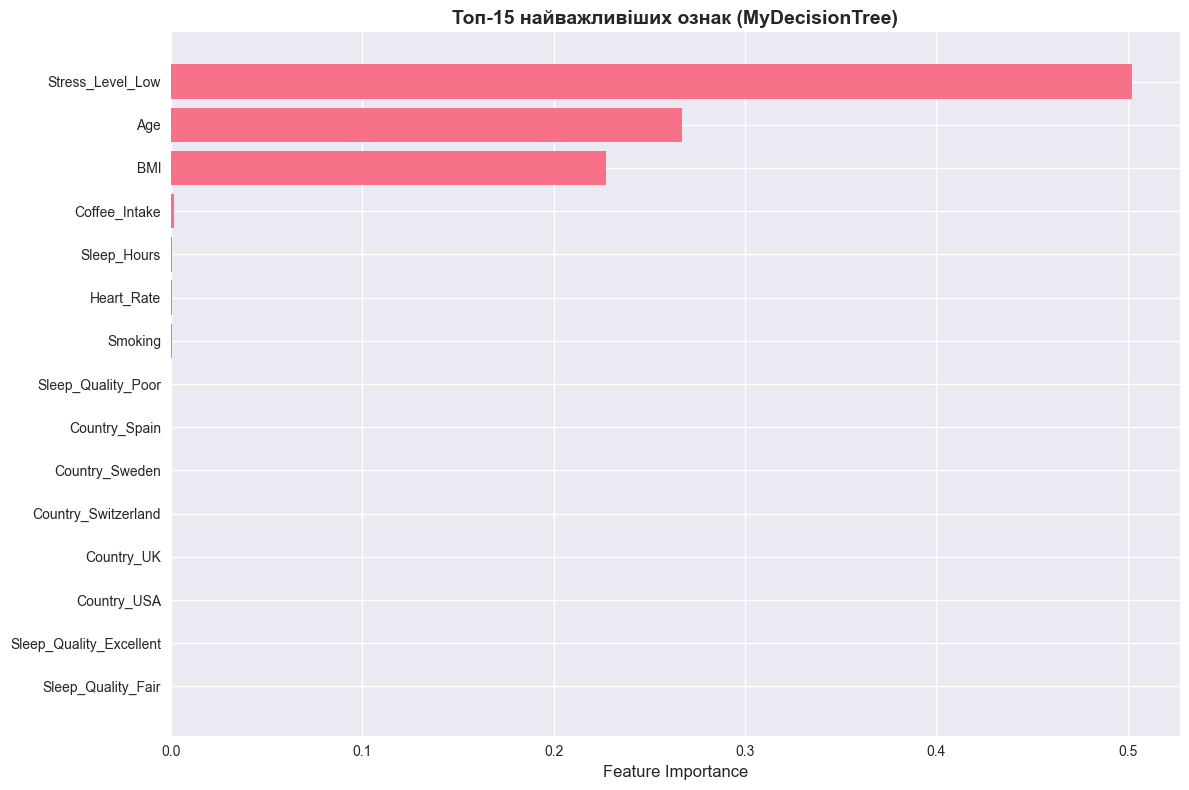

In [87]:
# 1. Візуалізація Feature Importance (MyDecisionTree)
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Топ-15 найважливіших ознак (MyDecisionTree)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


<Figure size 1400x800 with 0 Axes>

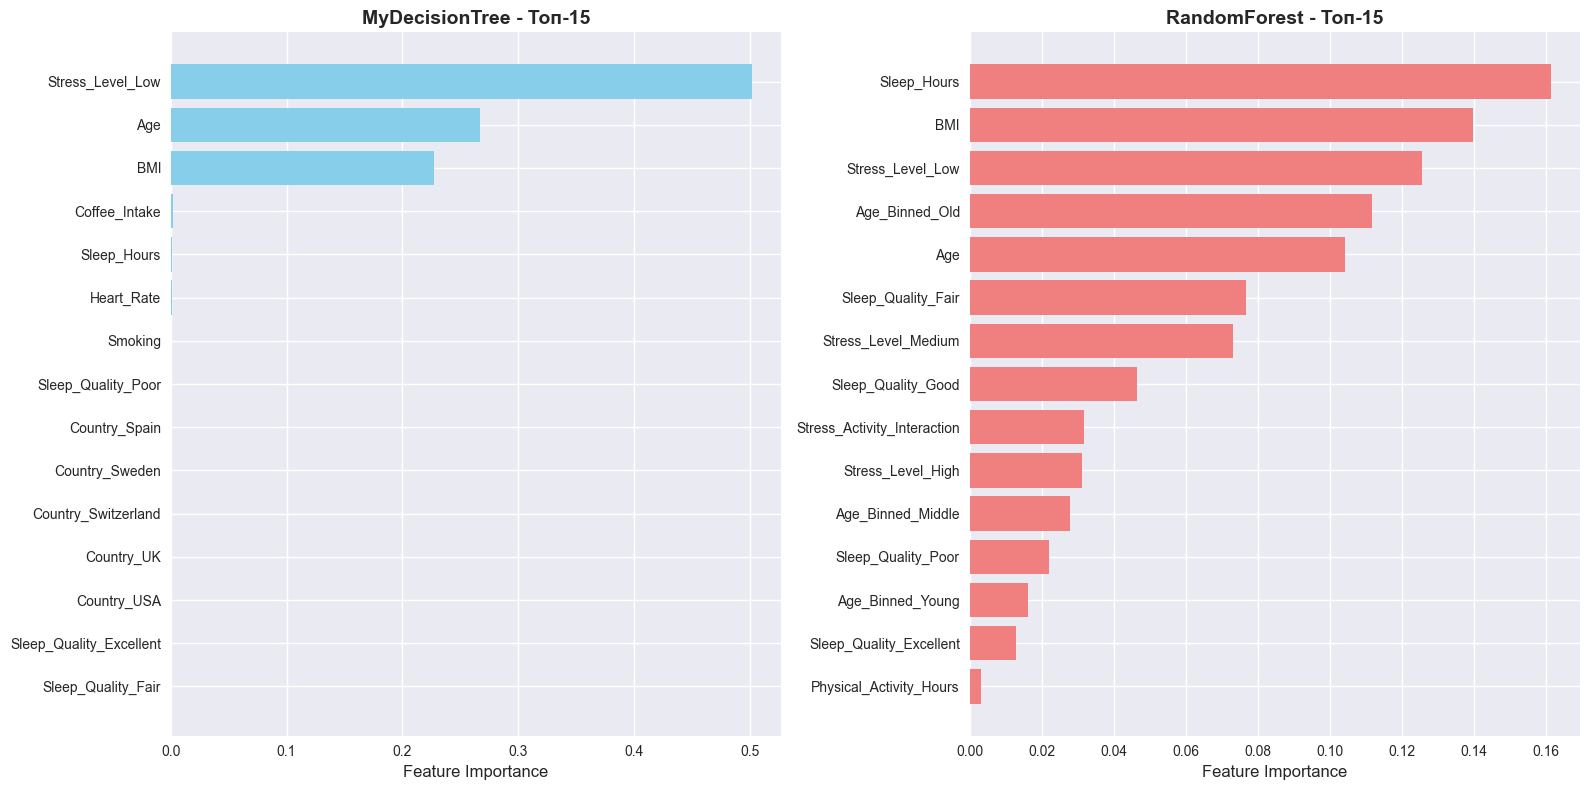

In [88]:
# 2. Порівняння Feature Importance: MyDecisionTree vs RandomForest
plt.figure(figsize=(14, 8))

# Топ-15 для обох моделей
top_15_my = importance_df.head(15)
top_15_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# MyDecisionTree
ax1.barh(range(len(top_15_my)), top_15_my['Importance'].values, color='skyblue')
ax1.set_yticks(range(len(top_15_my)))
ax1.set_yticklabels(top_15_my['Feature'].values)
ax1.set_xlabel('Feature Importance', fontsize=12)
ax1.set_title('MyDecisionTree - Топ-15', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# RandomForest
ax2.barh(range(len(top_15_rf)), top_15_rf['Importance'].values, color='lightcoral')
ax2.set_yticks(range(len(top_15_rf)))
ax2.set_yticklabels(top_15_rf['Feature'].values)
ax2.set_xlabel('Feature Importance', fontsize=12)
ax2.set_title('RandomForest - Топ-15', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()


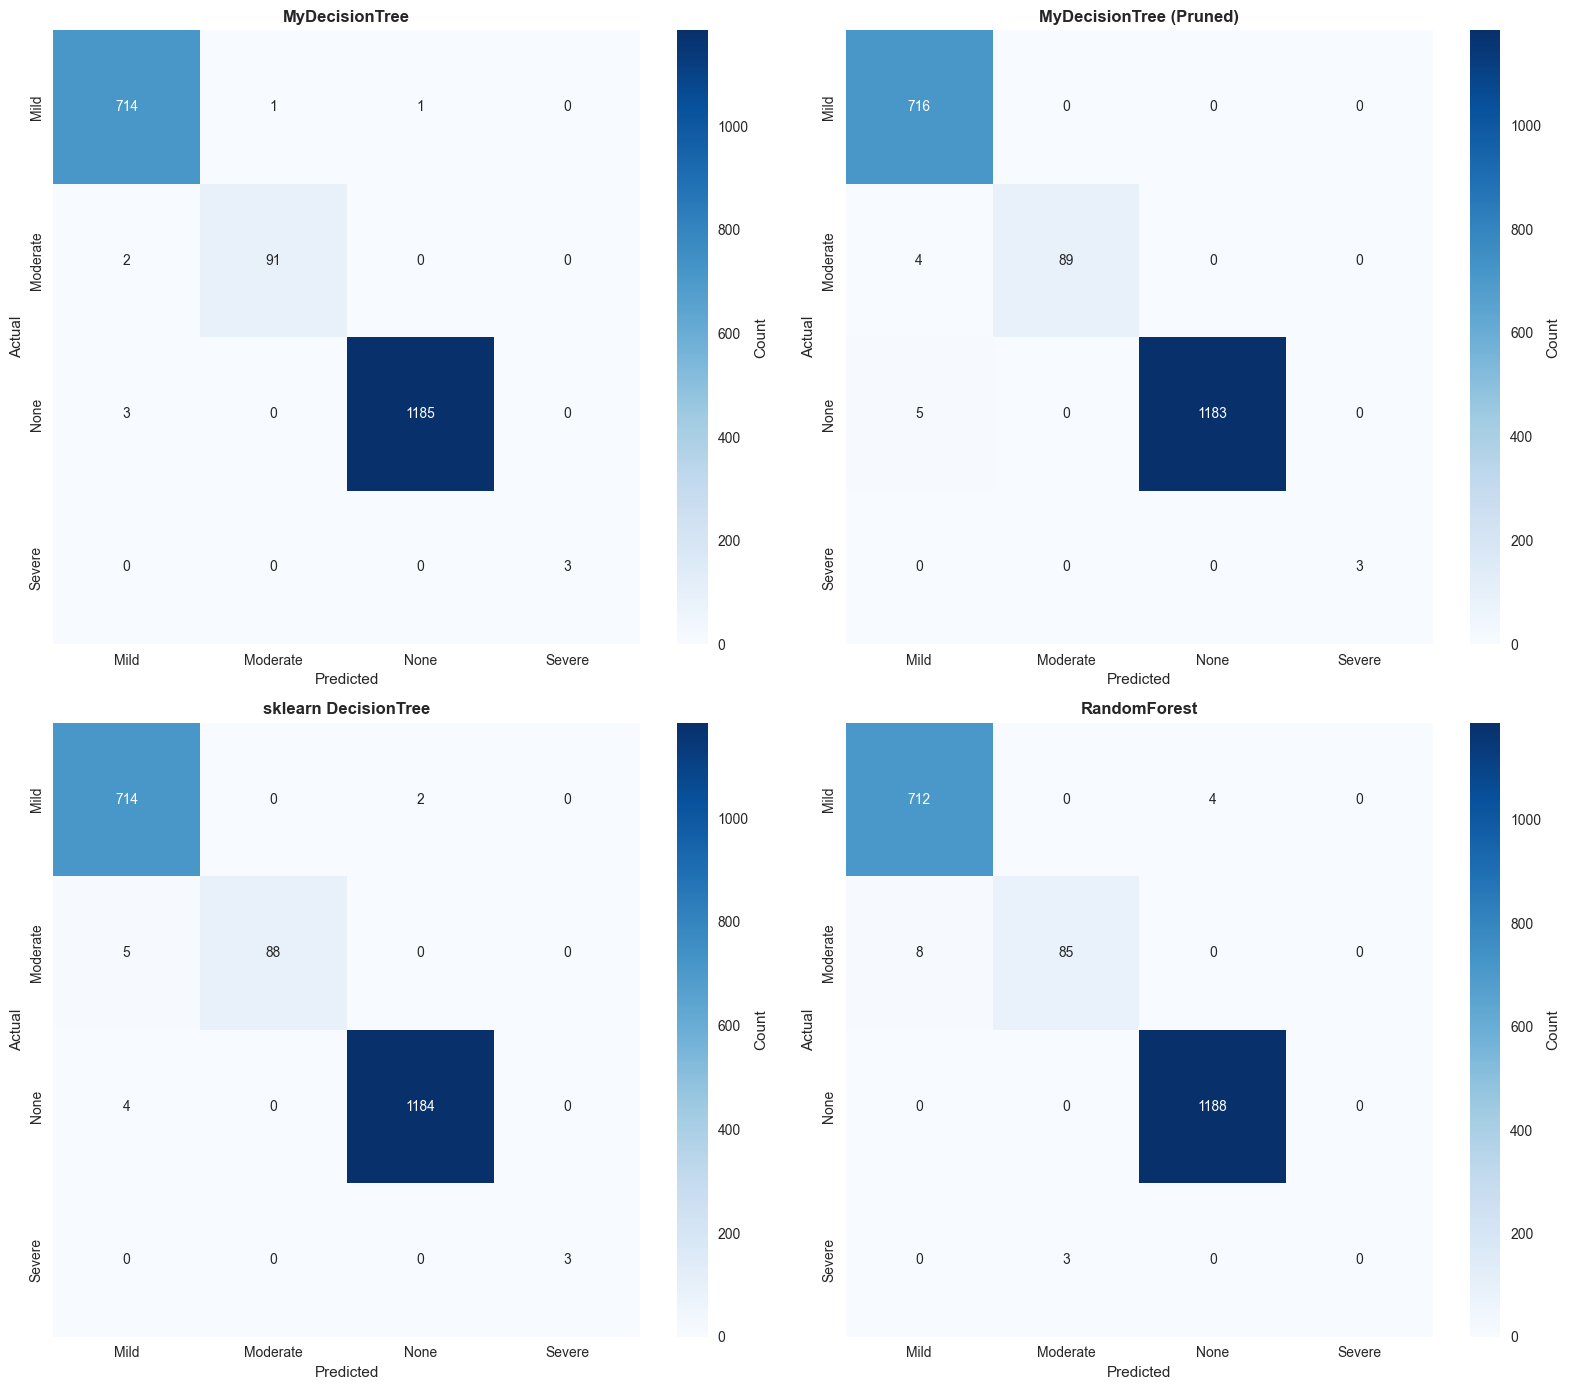

In [89]:
# 3. Confusion Matrices для всіх моделей
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

models = [
    (cm_my_tree, "MyDecisionTree", axes[0, 0]),
    (cm_pruned, "MyDecisionTree (Pruned)", axes[0, 1]),
    (cm_sklearn, "sklearn DecisionTree", axes[1, 0]),
    (cm_rf, "RandomForest", axes[1, 1])
]

class_names = label_encoder.classes_

for cm, title, ax in models:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


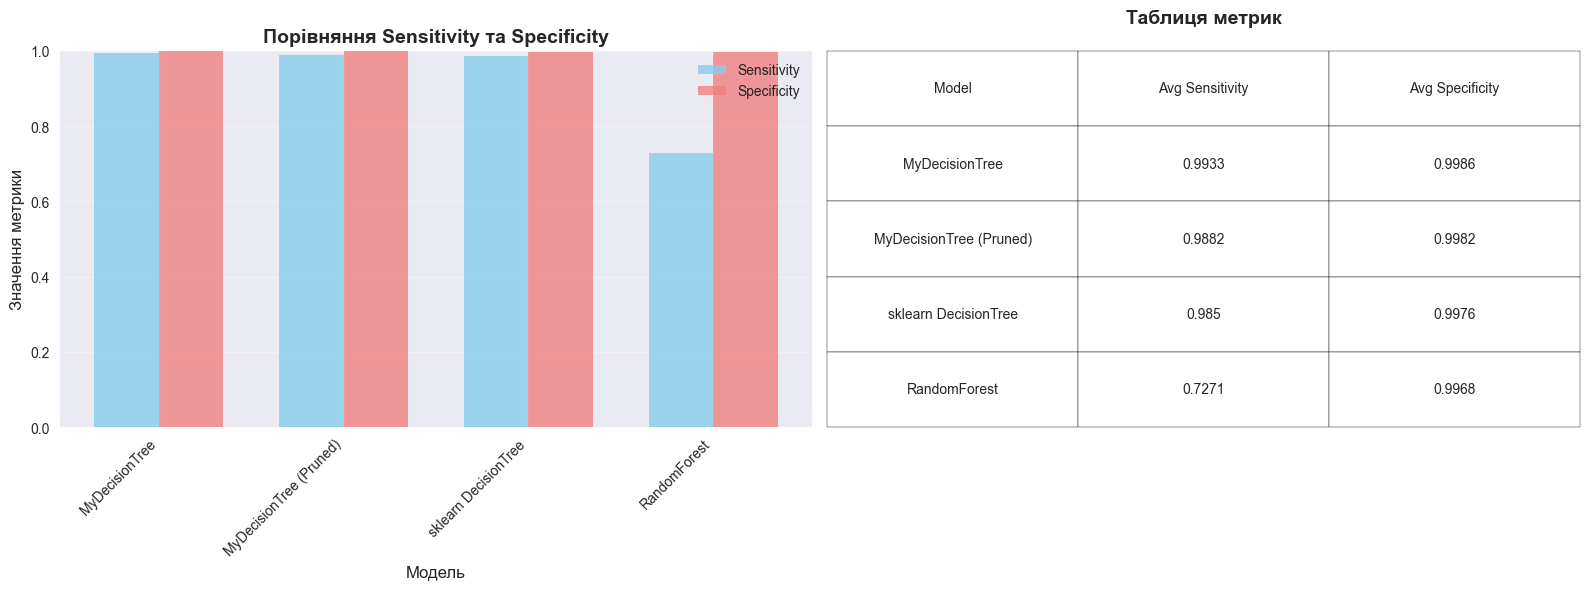

In [90]:
# 4. Порівняння метрик: Sensitivity та Specificity
models_metrics = {
    'MyDecisionTree': metrics_my_tree,
    'MyDecisionTree (Pruned)': metrics_pruned,
    'sklearn DecisionTree': metrics_sklearn,
    'RandomForest': metrics_rf
}

# Обчислюємо середні значення
avg_sensitivity = []
avg_specificity = []
model_names = []

for name, metrics in models_metrics.items():
    class_labels = np.arange(len(label_encoder.classes_))
    sens = np.mean([metrics[i]['Sensitivity'] for i in class_labels])
    spec = np.mean([metrics[i]['Specificity'] for i in class_labels])
    avg_sensitivity.append(sens)
    avg_specificity.append(spec)
    model_names.append(name)

# Створюємо DataFrame для візуалізації
metrics_comparison = pd.DataFrame({
    'Model': model_names,
    'Avg Sensitivity': avg_sensitivity,
    'Avg Specificity': avg_specificity
})

# Візуалізація
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(model_names))
width = 0.35

ax1.bar(x - width/2, avg_sensitivity, width, label='Sensitivity', color='skyblue', alpha=0.8)
ax1.bar(x + width/2, avg_specificity, width, label='Specificity', color='lightcoral', alpha=0.8)
ax1.set_xlabel('Модель', fontsize=12)
ax1.set_ylabel('Значення метрики', fontsize=12)
ax1.set_title('Порівняння Sensitivity та Specificity', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# Таблиця
ax2.axis('tight')
ax2.axis('off')
table = ax2.table(cellText=metrics_comparison.round(4).values,
                  colLabels=metrics_comparison.columns,
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax2.set_title('Таблиця метрик', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


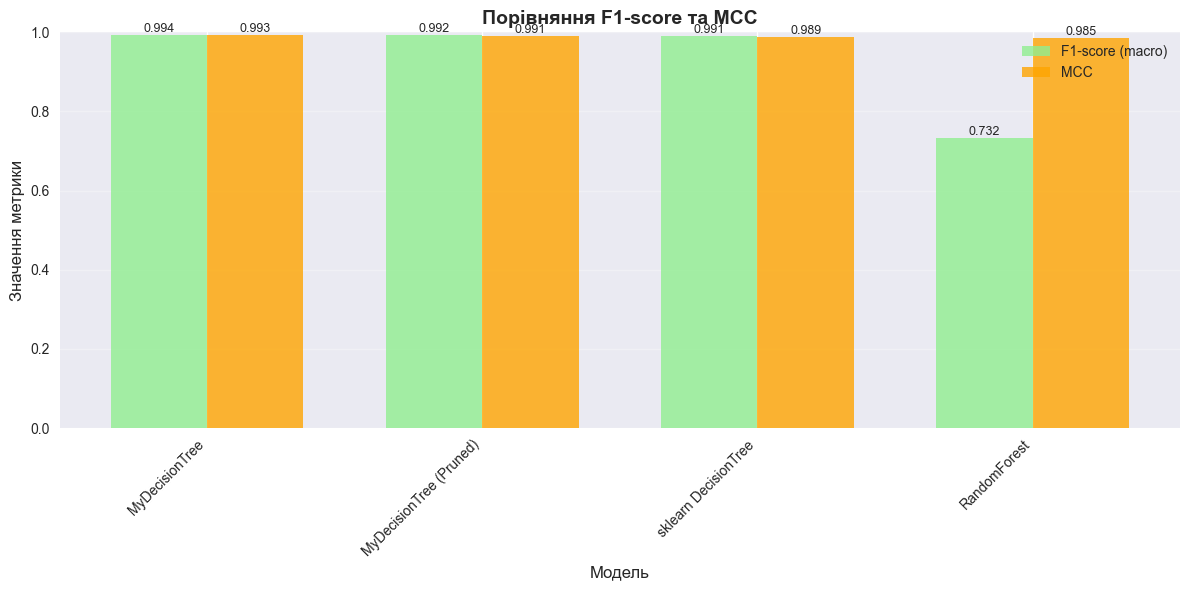

In [91]:
# 5. Порівняння F1-score та MCC
f1_scores = []
mcc_scores = []
model_names_short = []

for name, metrics in models_metrics.items():
    # Обчислюємо F1 та MCC для кожної моделі
    if name == 'MyDecisionTree':
        y_pred = y_pred_my_tree
    elif name == 'MyDecisionTree (Pruned)':
        y_pred = y_pred_pruned
    elif name == 'sklearn DecisionTree':
        y_pred = y_pred_sklearn
    else:
        y_pred = y_pred_rf
    
    f1 = f1_score(y_test, y_pred, average='macro')
    mcc = matthews_corrcoef(y_test, y_pred)
    
    f1_scores.append(f1)
    mcc_scores.append(mcc)
    model_names_short.append(name)

# Візуалізація
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_names_short))
width = 0.35

bars1 = ax.bar(x - width/2, f1_scores, width, label='F1-score (macro)', color='lightgreen', alpha=0.8)
bars2 = ax.bar(x + width/2, mcc_scores, width, label='MCC', color='orange', alpha=0.8)

ax.set_xlabel('Модель', fontsize=12)
ax.set_ylabel('Значення метрики', fontsize=12)
ax.set_title('Порівняння F1-score та MCC', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names_short, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

# Додаємо значення на стовпцях
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# 6. Порівняння Permutation Importance з Gini-based Importance
plt.figure(figsize=(14, 8))

# Топ-15 для обох методів
top_15_gini = importance_df.head(15)
top_15_perm = perm_importance_df.head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Gini-based
ax1.barh(range(len(top_15_gini)), top_15_gini['Importance'].values, color='steelblue')
ax1.set_yticks(range(len(top_15_gini)))
ax1.set_yticklabels(top_15_gini['Feature'].values)
ax1.set_xlabel('Importance', fontsize=12)
ax1.set_title('Gini-based Importance (Топ-15)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Permutation
ax2.barh(range(len(top_15_perm)), top_15_perm['Importance'].values, 
         xerr=top_15_perm['Std'].values, color='coral', alpha=0.8)
ax2.set_yticks(range(len(top_15_perm)))
ax2.set_yticklabels(top_15_perm['Feature'].values)
ax2.set_xlabel('Permutation Importance', fontsize=12)
ax2.set_title('Permutation Importance (Топ-15)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()


## 8. Аналіз результатів та висновки

### Порівняльний аналіз моделей

#### 1. MyDecisionTree vs sklearn DecisionTree
- **Очікуваний результат:** Схожі результати, оскільки обидві використовують Gini impurity
- **Можливі відмінності:** 
  - Різні стратегії пошуку порогів
  - Оптимізації в sklearn (Cython)
  - Обробка крайових випадків

#### 2. Вплив прунінгу
- **Очікуваний результат:** Прунінг може покращити або погіршити продуктивність
- **Якщо покращив:** Дерево було перенавчене, прунінг допоміг
- **Якщо погіршив:** Дерево було оптимальним, прунінг видалив важливі розділи

#### 3. RandomForest vs окремі дерева
- **Очікуваний результат:** RandomForest зазвичай кращий через:
  - Averaging прогнозів (зменшує варіативність)
  - Bootstrap sampling (різноманітність дерев)
  - Random feature selection (зменшує кореляцію)

#### 4. Feature Importance
- **Gini-based:** Швидкий розрахунок, але може переоцінювати важливість висококардинальних ознак
- **Permutation:** Більш надійна оцінка, враховує взаємодії, але повільніша

#### 5. Feature Selection
- **Очікуваний результат:** Може покращити продуктивність через зменшення шуму
- **Якщо погіршив:** Видалені важливі ознаки або їх взаємодії

### Висновки

1. **Власна реалізація** демонструє правильність алгоритму Gini-based дерева рішень
2. **Прунінг** є важливим інструментом для запобігання перенавчанню
3. **RandomForest** показує переваги ансамблю методів
4. **Feature engineering** та **feature selection** можуть значно покращити результати
5. **Sensitivity та Specificity** дають детальну інформацію про продуктивність по класах


In [92]:
# Feature selection на основі importance з MyDecisionTree
threshold = 0.01
selected_features_idx = np.where(my_tree.feature_importance > threshold)[0]

print(f"Вибрані ознаки (importance > {threshold}): {len(selected_features_idx)} з {len(feature_names)}")
print(f"\nТоп-15 найважливіших ознак:")
print(importance_df.head(15))


Вибрані ознаки (importance > 0.01): 3 з 49

Топ-15 найважливіших ознак:
                    Feature  Importance
39         Stress_Level_Low    0.502110
0                       Age    0.266883
3                       BMI    0.227379
1             Coffee_Intake    0.001583
2               Sleep_Hours    0.000782
4                Heart_Rate    0.000726
6                   Smoking    0.000538
37       Sleep_Quality_Poor    0.000000
29            Country_Spain    0.000000
30           Country_Sweden    0.000000
31      Country_Switzerland    0.000000
32               Country_UK    0.000000
33              Country_USA    0.000000
34  Sleep_Quality_Excellent    0.000000
35       Sleep_Quality_Fair    0.000000
